# 📊 This project builds a machine learning classification model to predict
# 🎓 Affects_Academic_Performance based on students’ 🧠 Mental_Health_Score
# and 📱 Conflicts_Over_Social_Media, aiming to analyze how psychological
# well-being and social media conflicts influence academic outcomes 🚀.

# Import Libraries 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [57]:
dataset = pd.read_csv(r"C:\Dataset for practice\Students Social Media Addiction.csv")
dataset.head(3)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9


# Select Features

In [60]:
df = dataset[['Mental_Health_Score','Conflicts_Over_Social_Media','Affects_Academic_Performance']]
df.head(3)

,Mental_Health_Score,Conflicts_Over_Social_Media,Affects_Academic_Performance
0,6,3,Yes
1,8,0,No
2,5,4,Yes


# 🧹Cleaning part

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Mental_Health_Score           705 non-null    int64 
 1   Conflicts_Over_Social_Media   705 non-null    int64 
 2   Affects_Academic_Performance  705 non-null    object
dtypes: int64(2), object(1)
memory usage: 16.7+ KB


In [65]:
df.isnull().sum().to_frame()

,0
Mental_Health_Score,0
Conflicts_Over_Social_Media,0
Affects_Academic_Performance,0


In [66]:
df.describe()

,Mental_Health_Score,Conflicts_Over_Social_Media
count,705.000000,705.000000
mean,6.226950,2.849645
std,1.105055,0.957968
min,4.000000,0.000000
25%,5.000000,2.000000
50%,6.000000,3.000000
75%,7.000000,4.000000
max,9.000000,5.000000


# 👀 Data Visualizations 

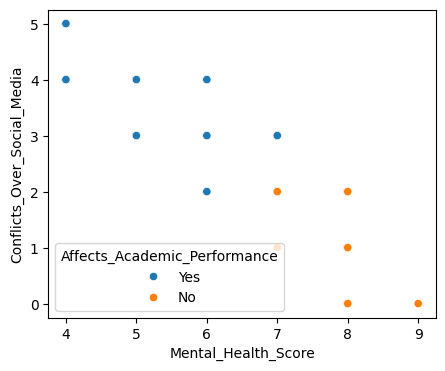

In [44]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='Mental_Health_Score',y='Conflicts_Over_Social_Media',data=df,hue='Affects_Academic_Performance')
plt.show()

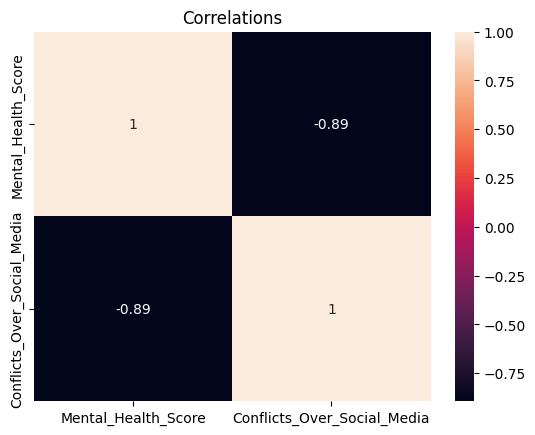

In [67]:
sns.heatmap(data=df[['Mental_Health_Score','Conflicts_Over_Social_Media']].corr(),annot=True)
plt.title('Correlations')
plt.show()

# Feature & Target Split

In [46]:
x = df[['Mental_Health_Score','Conflicts_Over_Social_Media']]
y = df['Affects_Academic_Performance']

# Train Test Split

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Model Create

In [68]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

# Model Training (Fit)

In [69]:
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 🤖 Model Evaluation 

# Confution Matrix

In [25]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [34]:
cm = confusion_matrix(y_test, lr.predict(x_test))
cm

array([[54,  0],
       [ 0, 87]])

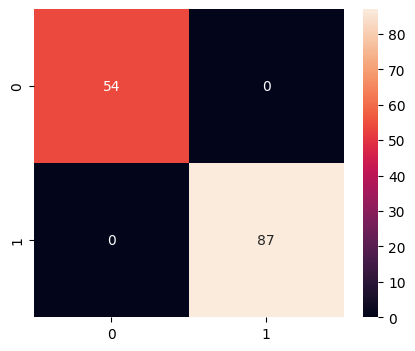

In [37]:
plt.figure(figsize=(5,4))
sns.heatmap(data=cm, annot=True)
plt.show()

# Model Accuracy

In [51]:
lr.score(x_test, y_test)*100

100.0

# Precision

In [40]:
precision_score(y_test, lr.predict(x_test),pos_label='Yes')*100

100.0

# Recall

In [41]:
recall_score(y_test, lr.predict(x_test),pos_label='Yes')*100

100.0

# F1-score

In [42]:
f1_score(y_test, lr.predict(x_test),pos_label='Yes')*100

100.0

# Prediction

In [73]:
import warnings
warnings.filterwarnings('ignore')

In [78]:
print(lr.predict([[8, 0]]))

['No']


In [84]:
print(lr.predict([[7, 3]]))

['Yes']


In [70]:
df.head(3)

,Mental_Health_Score,Conflicts_Over_Social_Media,Affects_Academic_Performance
0,6,3,Yes
1,8,0,No
2,5,4,Yes
